# Complex EDA: применимость методов решения M.Video NER

Ноутбук проверяет **гипотезы**, почему на наших данных уместны правила, weak BIO, CRF, классификаторы по кликам, трансформеры (в т.ч. multi-head), seq2seq и retrieval.

Подробный текстовый отчёт: [`README.md`](./README.md).

> Цель инференса: `query` → JSON фактов (`brand` / `category` / `attributes`) за &lt; 100 мс.  
> Клики и SKU — источники словарей, silver-разметки и fallback, не целевой текст парсинга.


## 0. Setup и загрузка семпла


In [2]:
%matplotlib inline
import sys
from pathlib import Path
from collections import Counter, defaultdict

ROOT = Path.cwd().resolve()
if ROOT.name in {"complex_eda", "notebooks"}:
    ROOT = ROOT.parents[1] if ROOT.name == "complex_eda" else ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_utils import (
    apply_plot_style,
    ensure_dirs,
    load_query_clicks,
    load_sku_desc,
    parquet_num_rows,
    parquet_schema_names,
    save_fig,
    save_stats,
    QUERY_CLICKS_PATH,
    SKU_DESC_PATH,
    SKUS_PKL_PATH,
    ARTIFACTS_DIR,
    FIGURES_DIR,
    MVIDEO_RED,
    DARK_SLATE,
    MUTED,
)
from src.ner.labeling import (
    ATTR_PATTERNS,
    WeakLabeler,
    bio_to_entities,
    entities_to_structured,
    tokenize,
)

ensure_dirs()
apply_plot_style()
FIG = FIGURES_DIR / "complex_eda"
FIG.mkdir(parents=True, exist_ok=True)

def save_local(fig, name: str):
    path = FIG / name
    fig.savefig(path, dpi=160, bbox_inches="tight", facecolor="white")
    print("saved", path)
    return path

SAMPLE_N = 200_000
print("ROOT:", ROOT)


ROOT: D:\Projects-26-06-2026\mvideo-ner-search


In [3]:
clicks = load_query_clicks(n=SAMPLE_N, seed=42, random=True)
desc = load_sku_desc(n=80_000, seed=42, random=True)

overview = pd.DataFrame([
    {"source": "query_clicks.parquet", "full_rows": parquet_num_rows(QUERY_CLICKS_PATH),
     "sample_rows": len(clicks), "role": "query + click SKU/brand/price/position"},
    {"source": "sku_desc.parquet", "full_rows": parquet_num_rows(SKU_DESC_PATH),
     "sample_rows": len(desc), "role": "title/description for dicts & embeddings"},
    {"source": "skus.pkl", "full_rows": SKUS_PKL_PATH.stat().st_size,
     "sample_rows": np.nan, "role": "YML catalog (bytes in full_rows)"},
])
overview


,source,full_rows,sample_rows,role
0,query_clicks.parquet,30991350,200000.0,query + click SKU/brand/price/position
1,sku_desc.parquet,1177200,80000.0,title/description for dicts & embeddings
2,skus.pkl,1565150311,NaN,YML catalog (bytes in full_rows)


In [4]:
q = clicks["query_text"].astype(str).str.strip()
ql = q.str.lower()
brand = clicks["sku_brand_name"].astype(str).str.strip()
brand_l = brand.str.lower()

summary = {
    "sample_rows": int(len(clicks)),
    "unique_queries": int(ql.nunique()),
    "unique_skus": int(clicks["sku_id"].nunique()),
    "unique_brands": int(brand.replace("", np.nan).nunique()),
    "unique_subjects": int(clicks["sku_subject_id"].nunique()),
    "query_tokens_p50": float(ql.str.split().str.len().quantile(0.50)),
    "query_tokens_p90": float(ql.str.split().str.len().quantile(0.90)),
    "query_tokens_p99": float(ql.str.split().str.len().quantile(0.99)),
    "query_chars_p50": float(ql.str.len().quantile(0.50)),
    "query_chars_p90": float(ql.str.len().quantile(0.90)),
    "price_median": float(clicks["sku_price"].median()),
    "nulls_query_text": int(clicks["query_text"].isna().sum()),
}
summary_df = pd.DataFrame(summary.items(), columns=["metric", "value"])
display(summary_df)

# brand explicitly present in query string
mask = brand_l.str.len() >= 2
hit = np.fromiter(
    (b in qq for qq, b in zip(ql[mask], brand_l[mask])),
    dtype=bool,
    count=int(mask.sum()),
)
print(f"brand_in_query: {hit.mean():.3%}  |  brand_absent_but_click: {(~hit).mean():.3%}")


,metric,value
0,sample_rows,200000.0
1,unique_queries,49144.0
2,unique_skus,59749.0
3,unique_brands,3139.0
4,unique_subjects,1870.0
5,query_tokens_p50,2.0
6,query_tokens_p90,4.0
7,query_tokens_p99,7.0
8,query_chars_p50,17.0
9,query_chars_p90,31.0


brand_in_query: 27.215%  |  brand_absent_but_click: 72.785%


## 1. Гипотеза: запросы короткие → правила и CRF уместны

Если p90 длины в токенах мала, exact-match словари и лёгкий CRF на CPU реалистичны для SLA &lt; 100 мс.


saved D:\Projects-26-06-2026\mvideo-ner-search\figures\complex_eda\01_query_length.png


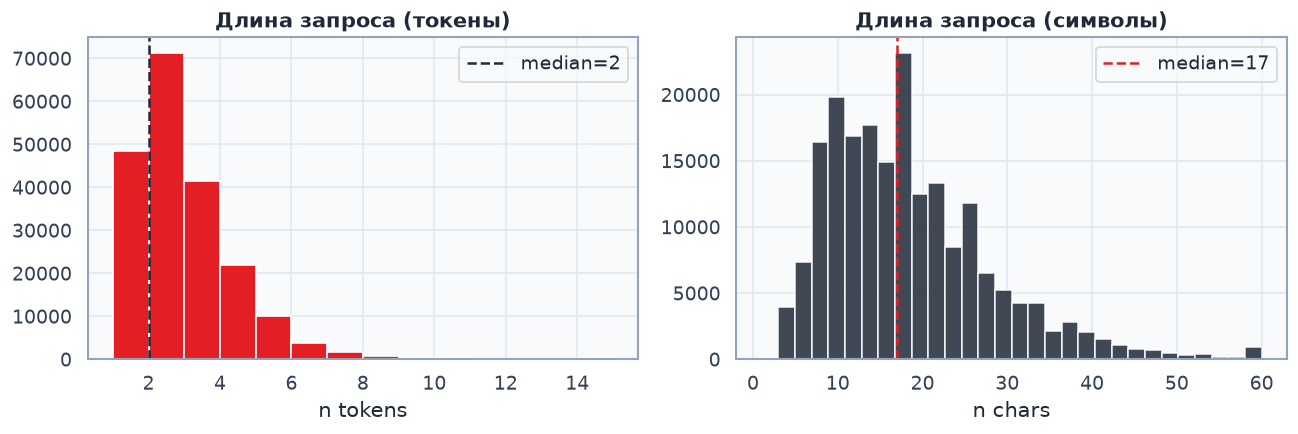

Вердикт: короткие строки → sequence labeling без тяжёлого контекста окна.


In [5]:
tok_n = ql.str.split().str.len()
char_n = ql.str.len()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(tok_n.clip(upper=15), bins=range(1, 16), color=MVIDEO_RED, edgecolor="white")
axes[0].axvline(tok_n.median(), color=DARK_SLATE, ls="--", label=f"median={tok_n.median():.0f}")
axes[0].set_title("Длина запроса (токены)")
axes[0].set_xlabel("n tokens")
axes[0].legend()

axes[1].hist(char_n.clip(upper=60), bins=30, color=DARK_SLATE, edgecolor="white", alpha=0.85)
axes[1].axvline(char_n.median(), color=MVIDEO_RED, ls="--", label=f"median={char_n.median():.0f}")
axes[1].set_title("Длина запроса (символы)")
axes[1].set_xlabel("n chars")
axes[1].legend()
fig.tight_layout()
save_local(fig, "01_query_length.png")
plt.show()

print("Вердикт: короткие строки → sequence labeling без тяжёлого контекста окна.")


## 2. Правила / словари + regex атрибутов

**Модель:** нет (gazetteer + regex).  
**Разметка:** совпадения → spans; regex → ATTR + тип (`memory`, `size`, …).

| Вход | Выход | Откуда |
|---|---|---|
| `ноутбук asus 16 гб` | CATEGORY/BRAND/ATTR(memory) | `brands.txt`, `categories.txt`, `ATTR_PATTERNS` |


dict brands=1,597  categories=1,009


,attr_type,share_of_clicks
2,size,0.012635
1,memory,0.007525
0,connectivity,0.006390
3,storage,0.002085
4,power,0.001995
6,dimensions,0.000825
5,resolution,0.000775


any ATTR-pattern share: 3.079%
saved D:\Projects-26-06-2026\mvideo-ner-search\figures\complex_eda\02_attr_regex_coverage.png


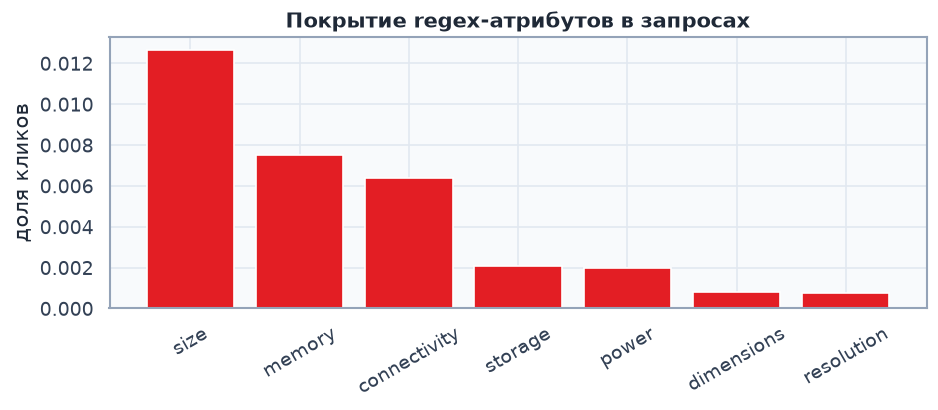

DEMO tags: [('ноутбук', 'B-CATEGORY'), ('asus', 'B-BRAND'), ('16', 'B-ATTR'), ('гб', 'I-ATTR')]
DEMO entities: [{'text': 'ноутбук', 'label': 'CATEGORY', 'span': [0, 7]}, {'text': 'asus', 'label': 'BRAND', 'span': [8, 12]}, {'text': '16 гб', 'label': 'ATTR', 'span': [13, 18]}]
DEMO structured: {'brand': 'Asus', 'category': 'ноутбук', 'attributes': {'memory': '16 гб'}}


In [6]:
labeler = WeakLabeler.from_files(
    ARTIFACTS_DIR / "brands.txt",
    ARTIFACTS_DIR / "categories.txt",
)
print(f"dict brands={len(labeler.brands):,}  categories={len(labeler.categories):,}")

# attr pattern coverage on sample (python re — надёжнее pandas+pyarrow)
cov = Counter()
any_attr = 0
for qq in ql:
    hit_any = False
    for pat, name in ATTR_PATTERNS:
        if pat.search(qq):
            cov[name] += 1
            hit_any = True
    if hit_any:
        any_attr += 1

attr_cov_df = (
    pd.DataFrame({"attr_type": list(cov.keys()), "share_of_clicks": [cov[k] / len(ql) for k in cov]})
    .sort_values("share_of_clicks", ascending=False)
)
display(attr_cov_df)
print(f"any ATTR-pattern share: {any_attr / len(ql):.3%}")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(attr_cov_df["attr_type"], attr_cov_df["share_of_clicks"], color=MVIDEO_RED)
ax.set_ylabel("доля кликов")
ax.set_title("Покрытие regex-атрибутов в запросах")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
save_local(fig, "02_attr_regex_coverage.png")
plt.show()

# demo typing: 16 гб → memory
demo_q = "ноутбук asus 16 гб"
tags = labeler.label_query(demo_q)
ents = bio_to_entities(tags, query=demo_q)
struct = entities_to_structured(ents, labeler=labeler)
print("DEMO tags:", tags)
print("DEMO entities:", ents)
print("DEMO structured:", struct)


### Как получается `16 гб` → `memory`?

В текущем пайплайне NER (и словарь) помечает span как **общий** `ATTR`, а тип (`memory` / `size` / `color`) выводится **постпроцессингом** (`_guess_attr_type` / имя regex-группы).

Альтернативы (см. README):
- мелкие BIO-классы: `B-MEMORY`, `B-COLOR`, …;
- вторая голова классификатора типа span;
- multi-head атрибутов (скорее для длинных карточек, чем для коротких запросов).


## 3. Weak supervision → BIO (данные для CRF/Transformer)

**Гипотеза:** словари из кликов дают достаточный coverage, чтобы учить sequence labeler без ручной разметки всего корпуса.


,metric,value
0,queries_labeled,12000.000000
1,share_with_any_entity,0.797583
2,share_with_BRAND,0.459583
3,share_with_CATEGORY,0.591333
4,share_with_ATTR,0.069167
5,share_multi_entity_types,0.293750
6,share_with_I_tag,0.269167


saved D:\Projects-26-06-2026\mvideo-ner-search\figures\complex_eda\03_bio_class_distribution.png


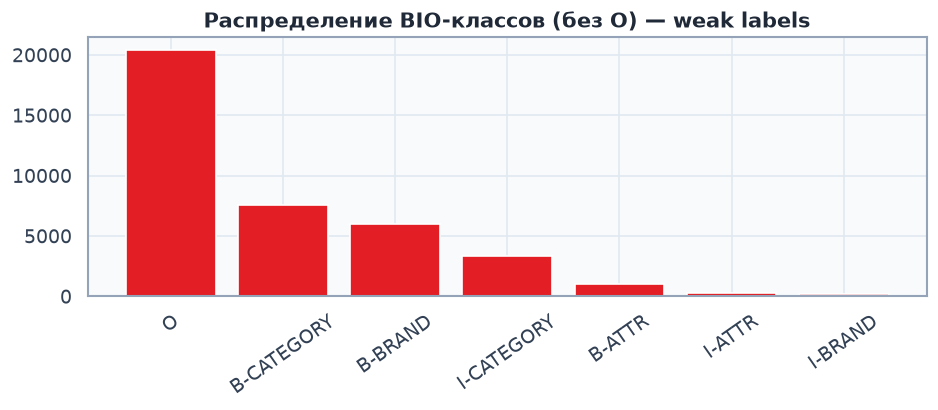

Примеры multi-entity разметки:
 Q: huawei matepad se 11 lte
 T: [('huawei', 'B-BRAND'), ('matepad', 'O'), ('se', 'O'), ('11', 'O'), ('lte', 'B-ATTR')]
 Q: наушники logitech g pro x se
 T: [('наушники', 'B-CATEGORY'), ('logitech', 'B-BRAND'), ('g', 'O'), ('pro', 'O'), ('x', 'O'), ('se', 'O')]
 Q: samsung galaxy s26 ultra
 T: [('samsung', 'B-BRAND'), ('galaxy', 'B-BRAND'), ('s26', 'B-CATEGORY'), ('ultra', 'I-CATEGORY')]
 Q: варочная панель индукционная midea
 T: [('варочная', 'B-CATEGORY'), ('панель', 'I-CATEGORY'), ('индукционная', 'I-CATEGORY'), ('midea', 'B-BRAND')]
 Q: яндекс станция алиса
 T: [('яндекс', 'B-BRAND'), ('станция', 'B-CATEGORY'), ('алиса', 'I-CATEGORY')]


In [17]:
uq = ql.drop_duplicates()
# ограничиваем для скорости; для полного прогона увеличьте N_WEAK
N_WEAK = 12_000
uq_sample = uq.head(N_WEAK).tolist()

stats = Counter()
n_with = n_brand = n_cat = n_attr = multi = n_i = 0
tag_hist = Counter()
examples = []

for query in uq_sample:
    tags = labeler.label_query(query)
    labs = [t for _, t in tags if t != "O"]
    if labs:
        n_with += 1
    types = {t[2:] for t in labs if t.startswith(("B-", "I-"))}
    if "BRAND" in types:
        n_brand += 1
    if "CATEGORY" in types:
        n_cat += 1
    if "ATTR" in types:
        n_attr += 1
    if len(types) >= 2:
        multi += 1
    if any(t.startswith("I-") for _, t in tags):
        n_i += 1
    for _, t in tags:
        tag_hist[t] += 1
    if len(examples) < 8 and len(types) >= 2:
        examples.append((query, tags))

m = len(uq_sample)
weak_table = pd.DataFrame([
    {"metric": "queries_labeled", "value": m},
    {"metric": "share_with_any_entity", "value": n_with / m},
    {"metric": "share_with_BRAND", "value": n_brand / m},
    {"metric": "share_with_CATEGORY", "value": n_cat / m},
    {"metric": "share_with_ATTR", "value": n_attr / m},
    {"metric": "share_multi_entity_types", "value": multi / m},
    {"metric": "share_with_I_tag", "value": n_i / m},
])
display(weak_table)

# BIO class distribution (excluding O dominance for readability)
bio_non_o = pd.Series({k: v for k, v in tag_hist.items()}).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(bio_non_o.index.astype(str), bio_non_o.values, color=MVIDEO_RED)
ax.set_title("Распределение BIO-классов (без O) — weak labels")
ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
save_local(fig, "03_bio_class_distribution.png")
plt.show()

print("Примеры multi-entity разметки:")
for query, tags in examples[:5]:
    print(" Q:", query)
    print(" T:", tags)


Классы — это **полные теги** (`B-BRAND`, `I-ATTR`, `O`, …), т.е. token-level multiclass, а не отдельно `{B,I,O}` и отдельно тип.


## 4. CRF NER

**Модель:** линейный-chain CRF; `P(y|x)` с фичами токена и transition scores.  
**Учится на:** `(tokens, BIO tags)` из weak labels.

| X | y | источник |
|---|---|---|
| фичи токенов запроса | последовательность BIO | п.3 |

**Гипотеза применимости:** есть multi-token сущности (`I-*` > 0) и несколько типов сразу — CRF оправдан относительно независимой классификации токенов.


In [ ]:
# Мини-обучение на подвыборке — smoke-test применимости (не полный бенчмарк)
from sklearn.model_selection import train_test_split
from src.ner.model_crf import CRFNerModel
from src.ner.features import sent2labels
from src.ner.metrics import summarize_metrics

sents = labeler.label_dataset(uq_sample, min_entities=1)
print("labeled sents with >=1 entity:", len(sents))

if len(sents) >= 400:
    train, test = train_test_split(sents, test_size=0.25, random_state=42)
    # ускорение smoke-test
    train_small = train[: min(2500, len(train))]
    model = CRFNerModel(max_iterations=40)
    model.fit(train_small)
    
    yt = [sent2labels(s) for s in test]
    yp = model.predict(test)
    report = summarize_metrics(yt, yp)
    crf_rows = [
        {"metric": "token_accuracy", "value": report.get("token_accuracy")},
        {"metric": "entity_micro_f1", "value": report.get("micro", {}).get("f1")},
    ]
    for lab, d in (report.get("per_label") or {}).items():
        crf_rows.append({"metric": f"f1_{lab}", "value": d.get("f1")})
    display(pd.DataFrame(crf_rows))

    # demo predict
    demo = "пылесос dyson v15"
    print("CRF predict:", model.predict_query(demo))
else:
    print("Мало размеченных предложений для smoke-test CRF")


labeled sents with >=1 entity: 9571


,metric,value
0,token_accuracy,0.909996
1,entity_micro_f1,0.875277
2,f1_ATTR,0.847118
3,f1_BRAND,0.949009
4,f1_CATEGORY,0.817794


CRF predict: [('пылесос', 'B-CATEGORY'), ('dyson', 'B-BRAND'), ('v15', 'O')]


In [ ]:
slice_idx = 3

sliced = sents[slice_idx]
print(*sliced)

('наушники', 'B-CATEGORY') ('logitech', 'B-BRAND') ('g', 'O') ('pro', 'O') ('x', 'O') ('se', 'O')


### Анализ разметки и возможные улучшения

*мысли*

Я прочекал руками что вообще лежит в текущей разметке, здесь мы наблюдаем напрямую, что подразумевается под "хвостом":

```
('наушники', 'B-CATEGORY') ('logitech', 'B-BRAND') ('g', 'O') ('pro', 'O') ('x', 'O') ('se', 'O')
```

Видим, что хвост типа `g pro` и далее - попусту не получают меток сущности, хотя у нас есть куча регулярок, которые по идее должны это увидеть. Чуть дальше рассмотрим, как это можно пофиксить и что хорошо работает с этими самыми хвостами. Идеал: присвоение BI-тега атрибута, и потом далее марковскими цепями присвоить тип атрибута.

Помечаю для себя:
- Важно, что в запросе в 74% случаев не написан бренд, а значит нам нужен полноценный классификатор бренда и категории.
- Поскольку нам важны атрибуты, делать миллиард голов под каждый тип формата "memory, diagonal" - просто не имеет смысла, попробуем доразвить идею с марковскими цепями (если после `16` вероятнее всего `ГБ`, то тип атрибута - memory.). Это классификатор, по всей видимости.

## 5. Классификаторы brand/category по кликам

**Гипотеза:** в &gt;70% кликов бренд **не** написан в запросе → span-NER недостаточен; нужен query-level classifier с лейблом из клика.


saved D:\Projects-26-06-2026\mvideo-ner-search\figures\complex_eda\04_brand_in_query_vs_click.png


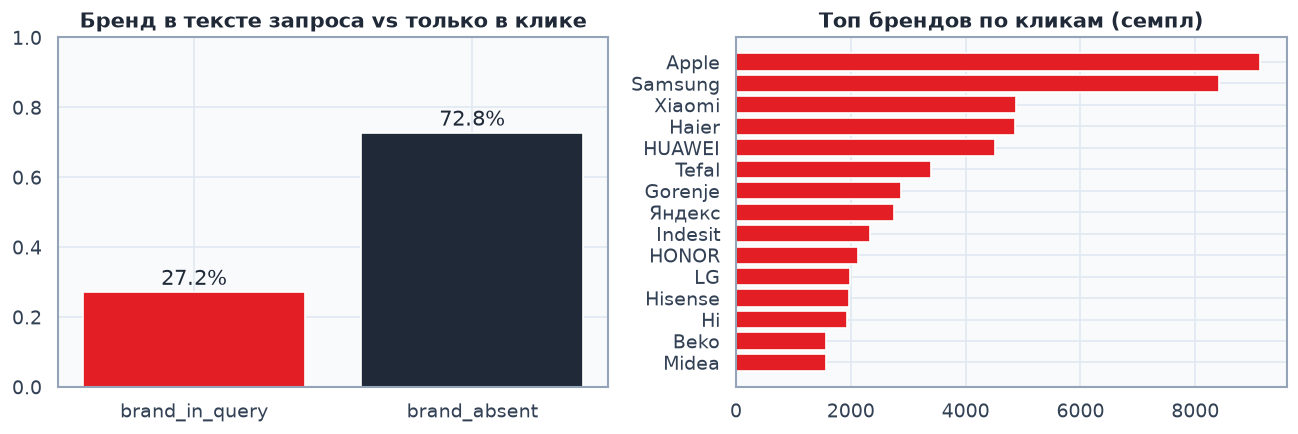

,metric,value
0,queries,49144.000000
1,queries_with_ge2_brands,8567.000000
2,share_ambiguous,0.174324


Пример обучения классификатора:
  X = query_text
  y = majority sku_brand_name по кликам этого query
  источник = query_clicks


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# left: brand present vs absent
share = pd.Series({"brand_in_query": hit.mean(), "brand_absent": (~hit).mean()})
axes[0].bar(share.index, share.values, color=[MVIDEO_RED, DARK_SLATE])
axes[0].set_ylim(0, 1)
axes[0].set_title("Бренд в тексте запроса vs только в клике")
for i, v in enumerate(share.values):
    axes[0].text(i, v + 0.02, f"{v:.1%}", ha="center")

# right: top brands concentration
vc = brand.replace("", np.nan).dropna().value_counts()
top = vc.head(15)
axes[1].barh(top.index[::-1], top.values[::-1], color=MVIDEO_RED)
axes[1].set_title("Топ брендов по кликам (семпл)")
fig.tight_layout()
save_local(fig, "04_brand_in_query_vs_click.png")
plt.show()

# ambiguity: same query → many brands
g = clicks.groupby(ql)["sku_brand_name"].nunique()
amb = pd.DataFrame({
    "metric": ["queries", "queries_with_ge2_brands", "share_ambiguous"],
    "value": [len(g), int((g >= 2).sum()), float((g >= 2).mean())],
})
display(amb)

print("Пример обучения классификатора:")
print("  X = query_text")
print("  y = majority sku_brand_name по кликам этого query")
print("  источник = query_clicks")


In [22]:
# Быстрый baseline: TF-IDF char ngrams + LogReg на majority brand (топ-K)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder

agg = (
    clicks.assign(query=ql, brand=brand)
    .loc[lambda d: d["brand"].str.len() >= 2]
    .groupby("query")["brand"]
    .agg(lambda s: s.value_counts().index[0])
    .reset_index()
)
# ограничиваем хвост: топ-40 брендов для smoke-test
top_brands = agg["brand"].value_counts().head(40).index
agg40 = agg[agg["brand"].isin(top_brands)].copy()
print("queries for clf:", len(agg40), "classes:", agg40["brand"].nunique())

le = LabelEncoder()
y = le.fit_transform(agg40["brand"])
Xtr, Xte, ytr, yte = train_test_split(agg40["query"], y, test_size=0.2, random_state=42, stratify=y)
vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=3, max_features=50_000)
Xtr_v = vec.fit_transform(Xtr)
Xte_v = vec.transform(Xte)
clf = LogisticRegression(max_iter=200, n_jobs=-1)
clf.fit(Xtr_v, ytr)
pred = clf.predict(Xte_v)
print(f"accuracy={accuracy_score(yte, pred):.3f}  macroF1={f1_score(yte, pred, average='macro'):.3f}")

# examples where brand not in query
miss_examples = []
for query, true_b in zip(Xte.iloc[:2000], le.inverse_transform(yte[:2000])):
    if true_b.lower() not in query.lower():
        miss_examples.append((query, true_b, le.inverse_transform(clf.predict(vec.transform([query])))[0]))
    if len(miss_examples) >= 6:
        break
pd.DataFrame(miss_examples, columns=["query", "click_brand", "pred_brand"])


queries for clf: 18914 classes: 40


d:\Projects-26-06-2026\mvideo-ner-search\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


accuracy=0.804  macroF1=0.768


,query,click_brand,pred_brand
0,айфон 15 про макс,Apple,Apple
1,редми ноут 13,Xiaomi,Xiaomi
2,холодильнике,Hisense,Haier
3,ноотбуки,ASUS,ASUS
4,аир подс,Apple,Apple
5,холодильники с нижней,Indesit,Haier


## 6. Трансформеры и multi-head

**Идея:** общий энкодер + несколько голов:

1. **NER head** — softmax по BIO на каждый токен (как CRF, но с contextual embeddings).
2. **Brand head** — классификация всего запроса (лейбл из клика).
3. **Category head** — аналогично.
4. Опционально **attr-type head** — тип span после детекции ATTR.

На коротких запросах это усиливает качество; для SLA часто оставляют cascade: правила → CRF → transformer только на low-confidence.

Ниже — **не** полный fine-tune (дорого в ноутбуке), а проверка, что есть совместный сигнал для multi-task: пересечение weak-BRAND и click-brand.


In [12]:
# Согласованность weak span-BRAND с брендом клика
rows = []
# возьмём подвыборку кликов
sub_idx = np.random.default_rng(42).choice(len(clicks), size=min(8000, len(clicks)), replace=False)
agree = 0
has_span = 0
for i in sub_idx:
    query = str(clicks.iloc[i]["query_text"])
    b = str(clicks.iloc[i]["sku_brand_name"]).strip()
    if len(b) < 2:
        continue
    tags = labeler.label_query(query)
    ents = bio_to_entities(tags, query=query)
    brands = [e["text"] for e in ents if e["label"] == "BRAND"]
    if brands:
        has_span += 1
        # canonical compare
        ok = any(b.lower() in br.lower() or br.lower() in b.lower() for br in brands)
        agree += int(ok)
        if len(rows) < 6:
            rows.append({"query": query, "click_brand": b, "span_brands": brands, "agree": ok})

print("among sampled clicks with brand: span vs click agreement")
print(f"agree_when_span / has_span = {agree}/{has_span} = {agree/max(has_span,1):.3%}")
display(pd.DataFrame(rows))

print("Схема multi-head (концепт):")
print("  Encoder(query)")
print("    |- Head_NER:   token -> BIO tags")
print("    |- Head_Brand: CLS -> brand_id (y из клика)")
print("    |- Head_Cat:   CLS -> category_id")
print("  Loss = L_ner + lambda_b * L_brand + lambda_c * L_cat")


among sampled clicks with brand: span vs click agreement
agree_when_span / has_span = 1559/1960 = 79.541%


,query,click_brand,span_brands,agree
0,huawei matebook,HUAWEI,[huawei],True
1,samsung s25,Samsung,[samsung],True
2,смартфоны samsung,Samsung,[samsung],True
3,зарядное устройство для iphone,Wireless,[iphone],False
4,OnePlus,OnePlus,[OnePlus],True
5,наушники soundcore,ANKER SOUNDCORE,[soundcore],True


Схема multi-head (концепт):
  Encoder(query)
    |- Head_NER:   token -> BIO tags
    |- Head_Brand: CLS -> brand_id (y из клика)
    |- Head_Cat:   CLS -> category_id
  Loss = L_ner + lambda_b * L_brand + lambda_c * L_cat


## 7. Seq2Seq / generative JSON

**Модель:** T5/LLM: `query → JSON`.  
**Учится на:** synthetic пары из weak entities (+ канонизация бренда).

Плюс: нормализация и вложенные атрибуты «из коробки».  
Минус: галлюцинации и latency — для online SLA лучше как **teacher/offline**, с проверкой «значение ⊆ query».


In [13]:
# Генерация synthetic seq2seq пар из weak labels (первые N)
pairs = []
for query in uq_sample[:3000]:
    tags = labeler.label_query(query)
    ents = bio_to_entities(tags, query=query)
    if not ents:
        continue
    struct = entities_to_structured(ents, labeler=labeler)
    pairs.append({"input": query, "output": struct})

seq_df = pd.DataFrame(pairs)
print("synthetic pairs:", len(seq_df))
display(seq_df.head(8))

# доля пар, где все entity.text являются подстроками input (anti-hallucination property of weak pipeline)
ok = 0
for r in pairs:
    texts = [e.get("text", "") for e in bio_to_entities(labeler.label_query(r["input"]), query=r["input"])]
    if all(t.lower() in r["input"].lower() for t in texts if t):
        ok += 1
print(f"substring-grounded pairs: {ok}/{len(pairs)} = {ok/max(len(pairs),1):.3%}")


synthetic pairs: 2435


,input,output
0,проточные водонагреватели,"{'brand': None, 'category': 'проточные водонаг..."
1,huawei matepad se 11 lte,"{'brand': 'HUAWEI', 'category': None, 'attribu..."
2,apple iphone 15,"{'brand': 'Apple', 'category': None, 'attribut..."
3,наушники logitech g pro x se,"{'brand': 'Logitech', 'category': 'наушники', ..."
4,роутеры,"{'brand': None, 'category': 'роутеры', 'attrib..."
5,электропила,"{'brand': None, 'category': 'электропила', 'at..."
6,микроволновая печь,"{'brand': None, 'category': 'микроволновая печ..."
7,samsung galaxy s26 ultra,"{'brand': 'Samsung', 'category': 's26 ultra', ..."


substring-grounded pairs: 2435/2435 = 100.000%


## 8. Эмбеддинги / retrieval query↔SKU

**Гипотеза:** пары кликов дают positives для nearest-neighbor; title SKU дополняет факты, которых нет в коротком запросе.


,query,top_sku_name,top_brand,score
0,стиральная машинка,Стиральная машина LG F4R5VYL0W,,0.594778
1,холодильники,Холодильник Nord NT 90 W,,0.564504
2,аэрогриль,Аэрогриль Аэрогриль электрический для дома 5 л...,нет бренда,0.784590
3,ноутбук,Ноутбук HP ProBook 460 G11 [A38BGET],HP,0.523210
4,микроволновая печь,Микроволновая печь Oursson Микроволновая печь ...,Oursson,0.874019
5,пылесос,Пылесос напольный нет Моющий пылесос,нет,0.720001
6,телевизор,Телевизор BQ 40F36B,BQ,0.705359
7,кондиционер сплит система,Кондиционер мобильный AERLU F2,AERLU,0.552406
8,электрические чайники,Электрочайник CF Чайник электрический CF-KG2181,CF,0.605956
9,холодильники двухкамерные,Холодильник двухкамерный HAIER CEF536CWG,HAIER,0.600030


saved D:\Projects-26-06-2026\mvideo-ner-search\figures\complex_eda\05_retrieval_scores.png


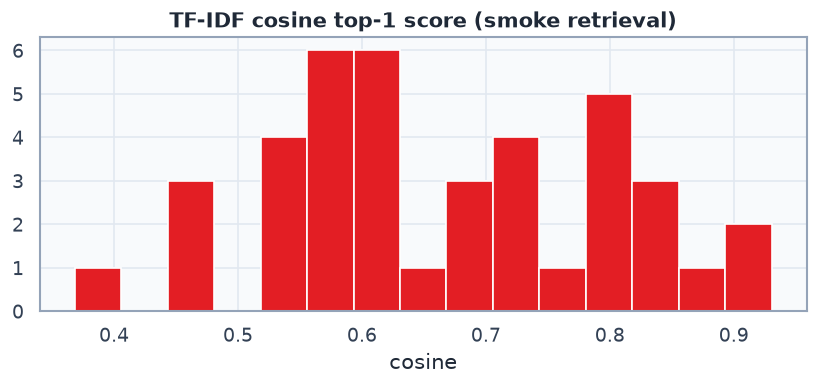

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# маленький retrieval smoke-test
sku_titles = (
    clicks[["sku_id", "sku_name", "sku_brand_name"]]
    .drop_duplicates("sku_id")
    .dropna(subset=["sku_name"])
    .head(12_000)
    .reset_index(drop=True)
)
# queries that appear often
q_freq = ql.value_counts().head(200).index.tolist()
eval_q = q_freq[:40]

vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2)
sku_m = vec.fit_transform(sku_titles["sku_name"].astype(str))
q_m = vec.transform(eval_q)

sims = cosine_similarity(q_m, sku_m)
top1 = sims.argmax(axis=1)
retr = pd.DataFrame({
    "query": eval_q,
    "top_sku_name": sku_titles.loc[top1, "sku_name"].values,
    "top_brand": sku_titles.loc[top1, "sku_brand_name"].values,
    "score": sims.max(axis=1),
})
display(retr.head(10))

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(retr["score"], bins=15, color=MVIDEO_RED, edgecolor="white")
ax.set_title("TF-IDF cosine top-1 score (smoke retrieval)")
ax.set_xlabel("cosine")
fig.tight_layout()
save_local(fig, "05_retrieval_scores.png")
plt.show()


## 9. RecSys-сигналы без user_id

Полноценный портрет пользователя недоступен (нет `user_id`). Используем позицию/цену как **веса доверия** к клику для обучения классификаторов.


saved D:\Projects-26-06-2026\mvideo-ner-search\figures\complex_eda\06_position_price.png


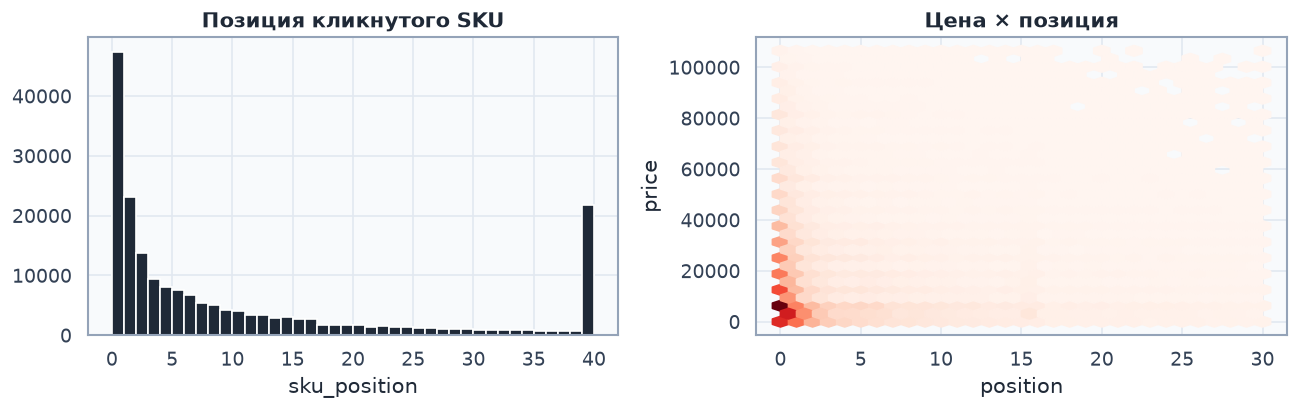

Практика: weight = 1/(1+position) при сборке majority brand / contrastive pairs.


In [15]:
pos = clicks["sku_position"].dropna()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(pos.clip(upper=40), bins=40, color=DARK_SLATE, edgecolor="white")
axes[0].set_title("Позиция кликнутого SKU")
axes[0].set_xlabel("sku_position")

sub = clicks[(clicks["sku_price"] > 0) & (clicks["sku_position"] <= 30)]
sub = sub[sub["sku_price"] < sub["sku_price"].quantile(0.95)]
axes[1].hexbin(sub["sku_position"], sub["sku_price"], gridsize=30, cmap="Reds", mincnt=3)
axes[1].set_title("Цена × позиция")
axes[1].set_xlabel("position")
axes[1].set_ylabel("price")
fig.tight_layout()
save_local(fig, "06_position_price.png")
plt.show()

print("Практика: weight = 1/(1+position) при сборке majority brand / contrastive pairs.")


## 10. Сводка: какой метод чем подтверждён


In [16]:
verdict = pd.DataFrame([
    {"method": "Правила / словари / regex", "eda_evidence": "короткие запросы; повторяемые бренды; regex ATTR", "role": "baseline + weak labels + typing"},
    {"method": "Weak BIO", "eda_evidence": "высокий share_with_any_entity; есть I-теги", "role": "silver dataset"},
    {"method": "CRF NER", "eda_evidence": "короткие seq; multi-type entities; CPU SLA", "role": "online span NER"},
    {"method": "TF-IDF + LogReg brand/cat", "eda_evidence": "~73% кликов без бренда в тексте", "role": "fallback классификации"},
    {"method": "Transformer multi-head", "eda_evidence": "есть BIO + click labels одновременно", "role": "качество / teacher"},
    {"method": "Seq2Seq → JSON", "eda_evidence": "synthetic grounded pairs из weak", "role": "offline / cold-start"},
    {"method": "Embeddings retrieval", "eda_evidence": "31M query→SKU пар", "role": "fallback поиска"},
    {"method": "RecSys weighting", "eda_evidence": "позиция/цена есть, user_id нет", "role": "чистка train"},
])
display(verdict)

out = {
    "summary": summary,
    "brand_in_query_rate": float(hit.mean()),
    "brand_absent_rate": float((~hit).mean()),
    "weak_coverage": {
        "n": m,
        "any_entity": n_with / m,
        "brand": n_brand / m,
        "category": n_cat / m,
        "attr": n_attr / m,
        "multi_type": multi / m,
        "has_I": n_i / m,
    },
    "attr_regex_any": any_attr / len(ql),
    "attr_regex_by_type": {k: cov[k] / len(ql) for k in cov},
}
save_stats(out, "complex_eda_method_stats.json")
print("Отчёт: notebooks/complex_eda/README.md")
print("Графики: figures/complex_eda/")


,method,eda_evidence,role
0,Правила / словари / regex,короткие запросы; повторяемые бренды; regex ATTR,baseline + weak labels + typing
1,Weak BIO,высокий share_with_any_entity; есть I-теги,silver dataset
2,CRF NER,короткие seq; multi-type entities; CPU SLA,online span NER
3,TF-IDF + LogReg brand/cat,~73% кликов без бренда в тексте,fallback классификации
4,Transformer multi-head,есть BIO + click labels одновременно,качество / teacher
5,Seq2Seq → JSON,synthetic grounded pairs из weak,offline / cold-start
6,Embeddings retrieval,31M query→SKU пар,fallback поиска
7,RecSys weighting,"позиция/цена есть, user_id нет",чистка train


Статистика сохранена: D:\Projects-26-06-2026\mvideo-ner-search\artifacts\complex_eda_method_stats.json
Отчёт: notebooks/complex_eda/README.md
Графики: figures/complex_eda/


# Небольшие выводы и мысли

Видим, что хвост типа `g pro` и далее - попусту не получают меток сущности, хотя у нас есть куча регулярок, которые по идее должны это увидеть. Чуть дальше рассмотрим, как это можно пофиксить и что хорошо работает с этими самыми хвостами. Идеал: присвоение BI-тега атрибута, и потом далее марковскими цепями присвоить тип атрибута.

Помечаю для себя:
- Важно, что в запросе в 74% случаев не написан бренд, а значит нам нужен полноценный классификатор бренда и категории.
- Поскольку нам важны атрибуты, делать миллиард голов под каждый тип формата "memory, diagonal" - просто не имеет смысла, попробуем доразвить идею с марковскими цепями (если после `16` вероятнее всего `ГБ`, то тип атрибута - memory.). Это классификатор, по всей видимости.